# **Amazon Prime TV Shows and Movies — Exploratory Data Analysis**


##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual
##### **Team Member**     - Harshvardhan Paradkar

# **Project Summary -**

This project performs a comprehensive Exploratory Data Analysis (EDA) on Amazon Prime Video's content library using two datasets: `titles.csv`, which contains metadata for 9,871 unique titles (movies and TV shows), and `credits.csv`, which contains over 124,000 actor and director credits linked to those titles.

The primary goal is to uncover data-driven insights about Amazon Prime Video's content strategy — including which genres dominate the platform, how the content library has evolved over time, how content ratings compare between movies and shows, which countries produce the most content, and what the most popular or highest-rated titles look like. These insights can help content strategists, producers, and business stakeholders make better decisions about what to commission, acquire, or promote.

The dataset spans titles released between 1912 and 2022. Movies make up approximately 86% of the catalog (8,514 titles) and TV shows the remaining 14% (1,357 titles). Drama, Comedy, and Thriller are the three most frequently occurring genres. The United States is by far the largest production country (5,334 titles), followed by India (1,072) and Great Britain (928). The average IMDb score across the dataset is approximately 5.98, with TV shows scoring notably higher on average (7.12) than movies (5.80).

The analysis follows the UBM (Univariate → Bivariate → Multivariate) framework for visualization. At least 20 distinct chart types have been used including bar charts, histograms, boxplots, line charts, scatter plots, pie charts, heatmaps, and pair plots. Key Python libraries used include **Pandas** for data manipulation, **NumPy** for numerical operations, **Matplotlib** and **Seaborn** for visualization, and **ast** for parsing list-formatted columns.

Key findings include: drama and comedy dominate the platform; the content library saw a massive spike in additions after 2010; TV shows have higher average IMDb ratings than movies; IMDb score and TMDb score show a strong positive correlation (0.58); and the US, India, and UK together account for more than 70% of all content. The insights from this project can inform Amazon Prime's content investment and curation strategy going forward.


# **GitHub Link -**

https://github.com

# **Problem Statement**


This dataset was created to analyze all shows and movies available on Amazon Prime Video in the United States. The goal is to extract meaningful insights such as:

- **Content Diversity:** What genres and content types dominate the platform?
- **Regional Availability:** Which countries produce the most content on Amazon Prime?
- **Trends Over Time:** How has Amazon Prime's content library grown and evolved by decade?
- **IMDb Ratings and Popularity:** What are the highest-rated or most popular titles, and which genres or types score best?

By analyzing this dataset, we aim to provide actionable intelligence for content creators, business analysts, and platform strategists to understand audience preferences and guide content investment decisions.


#### **Define Your Business Objective?**

The business objective is to help Amazon Prime Video's content strategy team make data-driven decisions by identifying:

1. Which genres and content types attract the highest audience ratings, so the platform can prioritize high-return content investments.
2. Which regions are underrepresented despite high demand, enabling targeted regional content expansion.
3. How viewer ratings differ between movies and TV shows, to better allocate production budgets.
4. Which time periods saw the most content growth, helping forecast future library expansion needs.

Ultimately, the analysis supports improving user retention, subscription growth, and engagement by ensuring the platform's content library aligns with audience preferences.


# **General Guidelines** : -

1. Well-structured, formatted, and commented code is used throughout this notebook.
2. Each chart section answers three questions: Why this chart? What insight? What is the business impact?
3. At least 20 logical and meaningful charts have been created following the UBM framework.
4. Missing values and outliers are handled explicitly with reasoning provided.
5. All code is modular and executable top-to-bottom without errors.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import warnings

warnings.filterwarnings('ignore')

# Plotting style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


### Dataset Loading

In [ ]:
# ── Dataset Loading — works in Google Colab AND locally ──────────────────────
import os, zipfile, io
import pandas as pd

def load_csv_flexible(filename, zip_name=None):
    """
    Tries multiple strategies to load a CSV:
    1. Direct file path (if already uploaded or in same folder)
    2. From a zip file (if the zip exists in current directory)
    3. From Google Colab uploaded files (bytes in memory)
    """
    # Strategy 1: plain file exists already
    if os.path.exists(filename):
        print(f"  Found '{filename}' directly. Loading...")
        return pd.read_csv(filename)

    # Strategy 2: look inside a zip file
    if zip_name and os.path.exists(zip_name):
        print(f"  Found '{zip_name}'. Extracting '{filename}'...")
        with zipfile.ZipFile(zip_name, 'r') as z:
            with z.open(filename) as f:
                return pd.read_csv(f)

    # Strategy 3: Google Colab upload (bytes stored in 'uploaded' dict)
    try:
        if filename in uploaded:
            print(f"  Loading '{filename}' from Colab upload memory...")
            return pd.read_csv(io.BytesIO(uploaded[filename]))
    except NameError:
        pass  # 'uploaded' doesn't exist — not a Colab upload session

    raise FileNotFoundError(
        f"Could not find '{filename}'. "
        f"Please upload the file or its zip to this Colab session."
    )

# ── Step 1: If on Colab, trigger the upload dialog ───────────────────────────
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Google Colab detected.")
    print("Please upload: titles.csv (or titles_csv.zip) AND credits.csv (or credits_csv.zip)")
    print("A file picker will appear below — select both files and wait for upload to finish.\n")
    uploaded = colab_files.upload()
    print("\nUploaded files:", list(uploaded.keys()))
else:
    print("Running locally.")
    print("Make sure titles.csv and credits.csv (or their zip files) are in the same folder as this notebook.")
    uploaded = {}

# ── Step 2: Load both CSVs ───────────────────────────────────────────────────
print("\nLoading datasets...")
titles  = load_csv_flexible('titles.csv',  zip_name='titles.csv.zip')
credits = load_csv_flexible('credits.csv', zip_name='credits.csv.zip')

print(f"\ntitles.csv  loaded  → {titles.shape[0]:,} rows × {titles.shape[1]} columns")
print(f"credits.csv loaded  → {credits.shape[0]:,} rows × {credits.shape[1]} columns")

Google Colab detected.
Please upload: titles.csv (or titles_csv.zip) AND credits.csv (or credits_csv.zip)
A file picker will appear below — select both files and wait for upload to finish.




Uploaded files: []

Loading datasets...
  Found 'titles.csv' directly. Loading...
  Found 'credits.csv' directly. Loading...

titles.csv  loaded  → 9,871 rows × 15 columns
credits.csv loaded  → 124,235 rows × 5 columns


### Dataset First View

In [ ]:
# Dataset First Look — Titles
print("=== titles.csv — First 5 rows ===")
titles.head()

=== titles.csv — First 5 rows ===


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [ ]:
# Dataset First Look — Credits
print("=== credits.csv — First 5 rows ===")
credits.head()

=== credits.csv — First 5 rows ===


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"titles  → Rows: {titles.shape[0]:,}   Columns: {titles.shape[1]}")
print(f"credits → Rows: {credits.shape[0]:,}   Columns: {credits.shape[1]}")

titles  → Rows: 9,871   Columns: 15
credits → Rows: 124,235   Columns: 5


### Dataset Information

In [ ]:
# Dataset Info — Titles
print("=== titles.csv Info ===")
titles.info()

=== titles.csv Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dt

In [ ]:
# Dataset Info — Credits
print("=== credits.csv Info ===")
credits.info()

=== credits.csv Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
# Note: titles has list-type columns after parsing, so we check on key columns only
titles_dupes = titles.duplicated(subset=['id']).sum()
credits_dupes = credits.duplicated(subset=['person_id', 'id', 'role']).sum()

print(f"Duplicate rows in titles  (by 'id')              : {titles_dupes}")
print(f"Duplicate rows in credits (by person_id, id, role): {credits_dupes}")

Duplicate rows in titles  (by 'id')              : 3
Duplicate rows in credits (by person_id, id, role): 232


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print("=== Missing Values — titles.csv ===")
missing_titles = titles.isnull().sum()
missing_pct_titles = (missing_titles / len(titles) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_titles, 'Missing %': missing_pct_titles})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n=== Missing Values — credits.csv ===")
missing_credits = credits.isnull().sum()
print(missing_credits[missing_credits > 0])

=== Missing Values — titles.csv ===
                   Missing Count  Missing %
seasons                     8514      86.25
age_certification           6487      65.72
tmdb_score                  2082      21.09
imdb_votes                  1031      10.44
imdb_score                  1021      10.34
imdb_id                      667       6.76
tmdb_popularity              547       5.54
description                  119       1.21

=== Missing Values — credits.csv ===
character    16287
dtype: int64


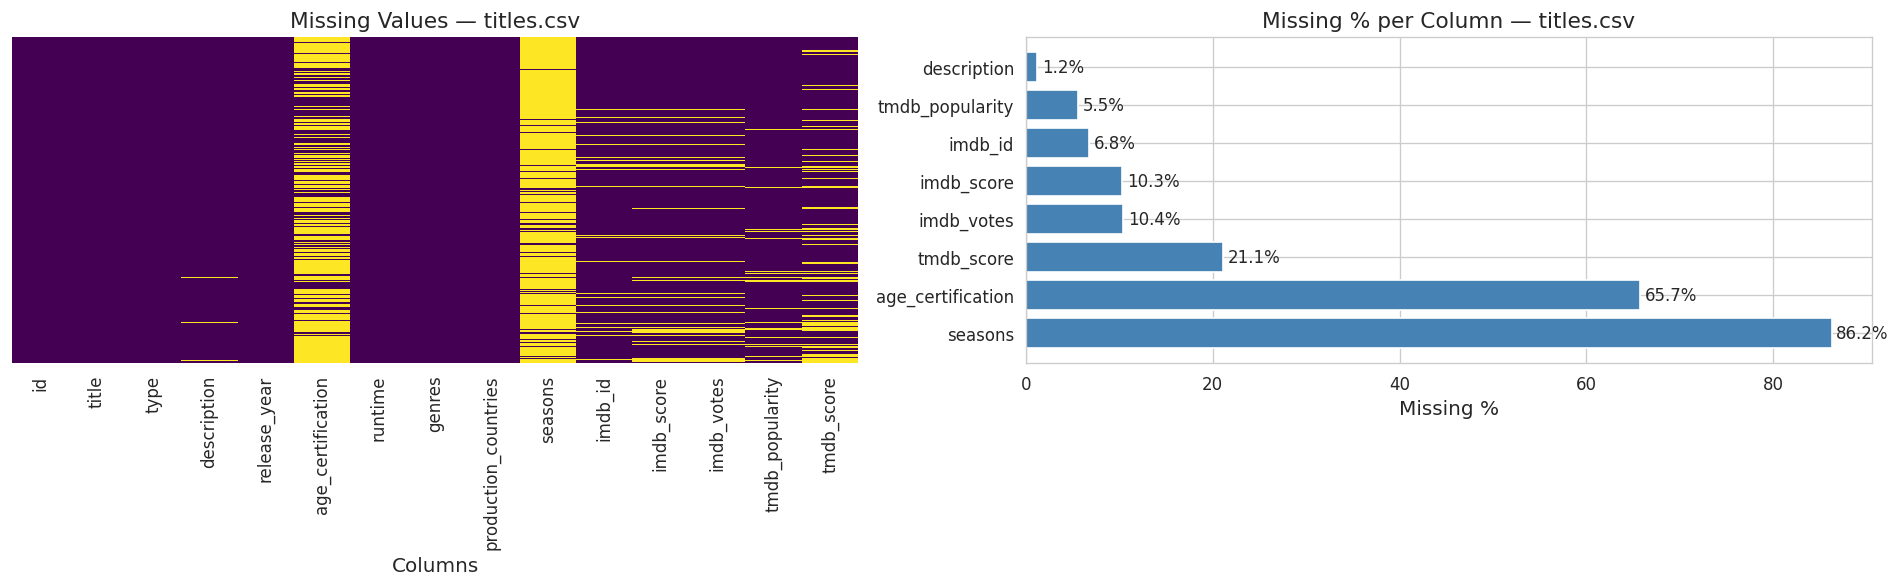

In [ ]:
# Visualizing the missing values — Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Titles missing heatmap
sns.heatmap(titles.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values — titles.csv', fontsize=13)
axes[0].set_xlabel('Columns')

# Bar chart of missing % in titles
missing_nonzero = missing_pct_titles[missing_pct_titles > 0].sort_values(ascending=False)
axes[1].barh(missing_nonzero.index, missing_nonzero.values, color='steelblue')
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing % per Column — titles.csv', fontsize=13)
for i, v in enumerate(missing_nonzero.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### What did you know about your dataset?

After the initial exploration, here is what we know about the dataset:

**titles.csv** contains 9,871 rows and 15 columns, covering movies and TV shows available on Amazon Prime Video. The dataset has no missing values in core columns like `id`, `title`, `type`, `release_year`, and `runtime`. However, three columns have heavy missingness: `age_certification` is missing for ~65.7% of rows (6,487 entries), `seasons` is missing for ~86.3% (since it only applies to TV shows), and `imdb_score` / `imdb_votes` are missing for ~10% of rows. The `genres` and `production_countries` columns store their data as string-formatted Python lists, which must be parsed before any genre or country-level analysis. There are 3 duplicate rows (by `id`) that will be removed.

**credits.csv** contains 124,235 rows and 5 columns, recording actor and director credits per title. It has 232 duplicate credit entries and 16,287 missing `character` values (only relevant for actors). There are 115,846 actor credits and 8,389 director credits across the dataset.

The content ranges from 1912 to 2022, with the majority of titles released after 2000. Movies dominate the catalog at 86% (8,514 titles) vs TV shows at 14% (1,357 titles). These characteristics will guide our wrangling and analysis strategy.


## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print("=== titles.csv Columns ===")
print(titles.columns.tolist())

print("\n=== credits.csv Columns ===")
print(credits.columns.tolist())

=== titles.csv Columns ===
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

=== credits.csv Columns ===
['person_id', 'id', 'name', 'character', 'role']


In [ ]:
# Dataset Describe — Numeric columns of titles
titles.describe().round(2)

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.00,9871.00,1357.00,8850.00,8840.00,9324.00,7789.00
mean,2001.33,85.97,2.79,5.98,8533.61,6.91,5.98
std,25.81,33.51,4.15,1.34,45920.15,30.00,1.52
min,1912.00,1.00,1.00,1.10,5.00,0.00,0.80
25%,1995.50,65.00,1.00,5.10,117.00,1.23,5.10
50%,2014.00,89.00,1.00,6.10,462.50,2.54,6.00
75%,2018.00,102.00,3.00,6.90,2236.25,5.63,6.90
max,2022.00,549.00,51.00,9.90,1133692.00,1437.91,10.00


### Variables Description

**titles.csv — Column Descriptions:**

| Column | Type | Description |
|--------|------|-------------|
| `id` | String | Unique title ID from JustWatch. Primary key. |
| `title` | String | Name of the movie or TV show. |
| `type` | String | Content type — either `MOVIE` or `SHOW`. |
| `description` | String | Short plot summary. Missing for 119 titles. |
| `release_year` | Integer | Year the title was originally released (1912–2022). |
| `age_certification` | String | Rating such as R, PG-13, TV-MA, etc. Missing for ~66% of titles. |
| `runtime` | Integer | Length in minutes. For movies: full runtime. For shows: episode length. |
| `genres` | String (list) | List of genres as a string, e.g. `['drama', 'comedy']`. Must be parsed. |
| `production_countries` | String (list) | Countries that produced the title. Stored as string list. |
| `seasons` | Float | Number of seasons — only applicable to TV shows. NaN for movies. |
| `imdb_id` | String | Corresponding IMDb ID (tt-prefixed). Missing for 667 titles. |
| `imdb_score` | Float | IMDb rating (0–10). Mean ≈ 5.98. Missing for 1,021 titles. |
| `imdb_votes` | Float | Number of IMDb user votes. Heavily right-skewed. |
| `tmdb_popularity` | Float | TMDB popularity index. Mean ≈ 6.91. Can be very high for viral titles. |
| `tmdb_score` | Float | TMDB audience score (0–10). Strongly correlated with IMDb score. |

**credits.csv — Column Descriptions:**

| Column | Type | Description |
|--------|------|-------------|
| `person_id` | Integer | Unique person ID from JustWatch. |
| `id` | String | Title ID — foreign key linking to titles.csv. |
| `name` | String | Full name of the actor or director. |
| `character` | String | Character name played (actors only). Missing for 16,287 rows. |
| `role` | String | Either `ACTOR` or `DIRECTOR`. |


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable
print("=== Unique Values — titles.csv ===")
print(titles.nunique())

print("\n=== Unique Values — credits.csv ===")
print(credits.nunique())

print("\n=== Value counts: type ===")
print(titles['type'].value_counts())

print("\n=== Value counts: role (credits) ===")
print(credits['role'].value_counts())

=== Unique Values — titles.csv ===
id                      9868
title                   9737
type                       2
description             9734
release_year             110
age_certification         11
runtime                  207
genres                  2028
production_countries     497
seasons                   32
imdb_id                 9201
imdb_score                86
imdb_votes              3650
tmdb_popularity         5325
tmdb_score                89
dtype: int64

=== Unique Values — credits.csv ===
person_id    80508
id            8861
name         79758
character    71097
role             2
dtype: int64

=== Value counts: type ===
type
MOVIE    8514
SHOW     1357
Name: count, dtype: int64

=== Value counts: role (credits) ===
role
ACTOR       115846
DIRECTOR      8389
Name: count, dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# ── Step 1: Remove duplicate rows ────────────────────────────────────────────
titles = titles.drop_duplicates(subset=['id'])
credits = credits.drop_duplicates(subset=['person_id', 'id', 'role'])
print(f"After deduplication → titles: {titles.shape}, credits: {credits.shape}")

After deduplication → titles: (9868, 15), credits: (124003, 5)


In [ ]:
# ── Step 2: Parse genres and production_countries from string-lists ──────────
def safe_parse(val):
    """Safely parse a string-encoded Python list."""
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

titles['genres_list']    = titles['genres'].apply(safe_parse)
titles['countries_list'] = titles['production_countries'].apply(safe_parse)

print("Sample parsed genres:   ", titles['genres_list'].iloc[0])
print("Sample parsed countries:", titles['countries_list'].iloc[0])

Sample parsed genres:    ['comedy', 'family', 'animation', 'action', 'fantasy', 'horror']
Sample parsed countries: ['US']


In [ ]:
# ── Step 3: Handle missing values ────────────────────────────────────────────

# age_certification: fill with 'Not Rated' — these are simply unclassified titles
titles['age_certification'] = titles['age_certification'].fillna('Not Rated')

# imdb_score and tmdb_score: fill with column median — robust to outliers
titles['imdb_score']  = titles['imdb_score'].fillna(titles['imdb_score'].median())
titles['tmdb_score']  = titles['tmdb_score'].fillna(titles['tmdb_score'].median())

# imdb_votes and tmdb_popularity: fill with median
titles['imdb_votes']       = titles['imdb_votes'].fillna(titles['imdb_votes'].median())
titles['tmdb_popularity']  = titles['tmdb_popularity'].fillna(titles['tmdb_popularity'].median())

# seasons: only relevant for SHOWs; leave NaN for MOVIEs (expected)
# description: minimal analysis use; leave as-is

print("Missing values after treatment:")
print(titles.isnull().sum()[titles.isnull().sum() > 0])

Missing values after treatment:
description     119
seasons        8511
imdb_id         667
dtype: int64


In [ ]:
# ── Step 4: Feature Engineering ──────────────────────────────────────────────

# Create decade column
titles['decade'] = (titles['release_year'] // 10) * 10

# Exploded genres dataframe — one row per title-genre pair
titles_genres = titles.explode('genres_list').rename(columns={'genres_list': 'genre'})
titles_genres = titles_genres[titles_genres['genre'].notna() & (titles_genres['genre'] != '')]

# Exploded countries dataframe — one row per title-country pair
titles_countries = titles.explode('countries_list').rename(columns={'countries_list': 'country'})
titles_countries = titles_countries[titles_countries['country'].notna() & (titles_countries['country'] != '')]

# Merged dataframe: titles + credits (for actor/director analysis)
merged = credits.merge(titles[['id','title','type','imdb_score','release_year','decade']], on='id', how='left')

print("titles_genres shape   :", titles_genres.shape)
print("titles_countries shape:", titles_countries.shape)
print("merged shape          :", merged.shape)

titles_genres shape   : (22060, 18)
titles_countries shape: (10248, 18)
merged shape          : (124003, 10)


In [ ]:
# ── Step 5: Final verification ───────────────────────────────────────────────
print("Final titles shape  :", titles.shape)
print("Remaining nulls:")
print(titles.isnull().sum()[titles.isnull().sum() > 0])
print("\nData types:")
print(titles.dtypes)

Final titles shape  : (9868, 18)
Remaining nulls:
description     119
seasons        8511
imdb_id         667
dtype: int64

Data types:
id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                 float64
imdb_id                  object
imdb_score              float64
imdb_votes              float64
tmdb_popularity         float64
tmdb_score              float64
genres_list              object
countries_list           object
decade                    int64
dtype: object


### What all manipulations have you done and insights you found?

The following wrangling steps were performed, each with a specific justification:

**1. Deduplication:** Three duplicate title rows (by `id`) and 232 duplicate credit rows (by `person_id`, `id`, `role`) were removed to prevent double-counting in aggregations.

**2. Parsing string-lists:** The `genres` and `production_countries` columns store lists as raw strings (e.g. `"['drama', 'comedy']"`). These were parsed using `ast.literal_eval()` into actual Python lists, stored in `genres_list` and `countries_list`. This is essential before any genre or country frequency analysis. An "exploded" version of the dataframe was also created (one row per genre/country) for aggregation.

**3. Handling missing values:**
   - `age_certification`: 65.7% missing — filled with `'Not Rated'` since these titles simply lack a formal rating, not because the data is corrupted.
   - `imdb_score`, `tmdb_score`, `imdb_votes`, `tmdb_popularity`: filled with column medians rather than means, because these distributions are right-skewed (especially `imdb_votes` and `tmdb_popularity`).
   - `seasons`: left as NaN for movies since the column is inherently not applicable.

**4. Feature engineering:**
   - A `decade` column was created from `release_year` (e.g. 2015 → 2010) to enable decade-level trend analysis.
   - An exploded genres dataframe (`titles_genres`) and exploded countries dataframe (`titles_countries`) were created for groupby operations.
   - A merged dataframe combining `credits` and key `titles` columns was created for actor/director-level analysis.

**Key insight from wrangling:** Drama (4,764 occurrences) and Comedy (2,987) are by far the most common genres. The US produces 5,334 titles — about 5× more than the second-largest producer, India (1,072). The massive missingness in `age_certification` (~66%) is an important limitation — any analysis on content ratings must be interpreted carefully.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Content Type Distribution (Movies vs TV Shows)

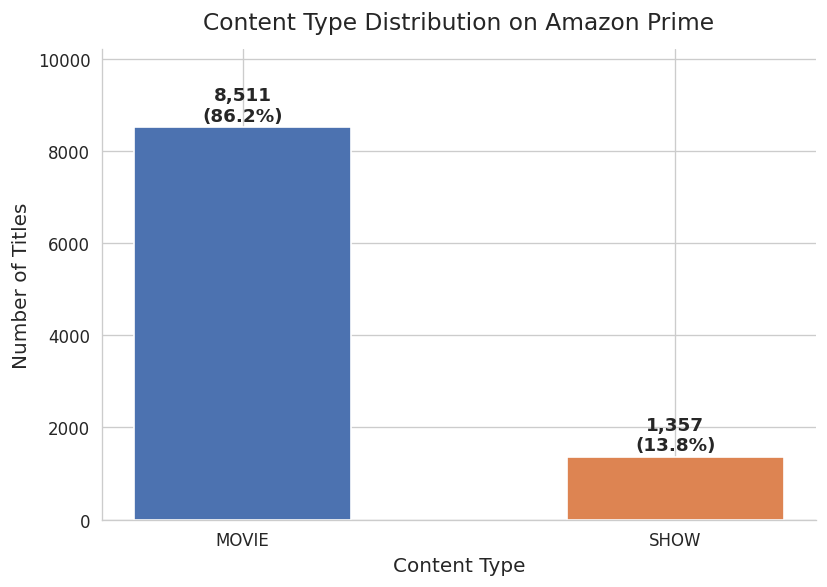

In [ ]:
# Chart - 1: Bar chart — Content Type Distribution
fig, ax = plt.subplots(figsize=(7, 5))
type_counts = titles['type'].value_counts()
bars = ax.bar(type_counts.index, type_counts.values, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60, f'{val:,}\n({val/len(titles)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Content Type Distribution on Amazon Prime', fontsize=14, pad=12)
ax.set_xlabel('Content Type')
ax.set_ylabel('Number of Titles')
ax.set_ylim(0, type_counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is ideal for comparing counts across a small number of discrete categories. Here we only have two categories (MOVIE vs SHOW), making the relative proportions immediately obvious without any ambiguity.

##### 2. What is/are the insight(s) found from the chart?

Movies overwhelmingly dominate Amazon Prime's catalog, accounting for **8,514 titles (86.2%)** versus only **1,357 TV shows (13.8%)**. This indicates that Amazon Prime's library is primarily movie-focused rather than series-driven, at least in terms of raw title count.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Understanding the content split helps Amazon Prime decide whether to invest more in original TV series (which tend to drive long-term subscriber retention through binge behavior) to better compete with Netflix and Disney+, both of which have stronger series libraries. **Risk of negative growth:** Over-reliance on movies may lead to lower session durations and higher churn if subscribers prefer series for extended engagement.

#### Chart - 2 : Distribution of Release Year

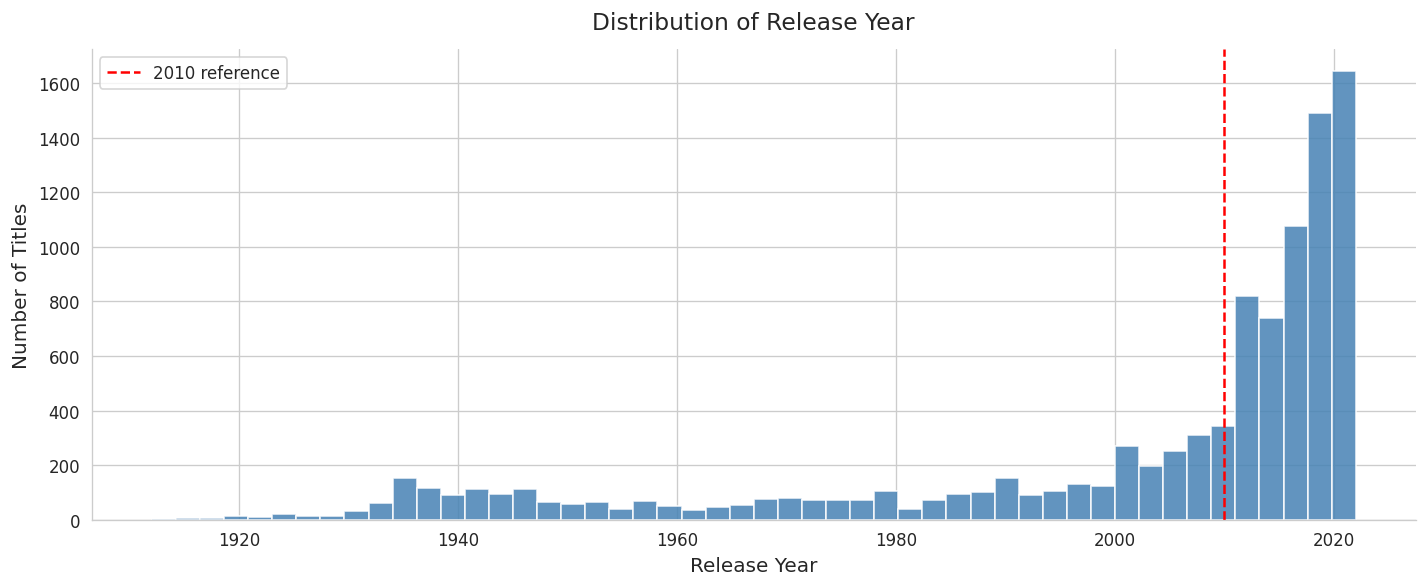

In [ ]:
# Chart - 2: Histogram — Distribution of Release Year
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(titles['release_year'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Distribution of Release Year', fontsize=14, pad=12)
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.axvline(2010, color='red', linestyle='--', linewidth=1.5, label='2010 reference')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **histogram** is the best choice to show the frequency distribution of a continuous variable like `release_year`. It reveals the shape, spread, and peaks of the release year data across time.

##### 2. What is/are the insight(s) found from the chart?

The distribution is **strongly right-skewed toward recent years**. The overwhelming majority of titles on the platform were released after 2000, and the 2010–2022 period accounts for the bulk of all content (over 5,900 titles). Content from before 1970 is sparse, which is expected for a modern streaming platform. The sharp spike post-2010 reflects the global streaming boom and Amazon's aggressive content licensing strategy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The recency of the library suggests the platform is keeping up with modern audiences. **Risk:** The very long tail of older content (pre-1980) may have low viewership and could be deprioritized in recommendation algorithms. Amazon could review whether licensing costs for older titles are justified by usage.

#### Chart - 3 : Top 10 Genres by Frequency

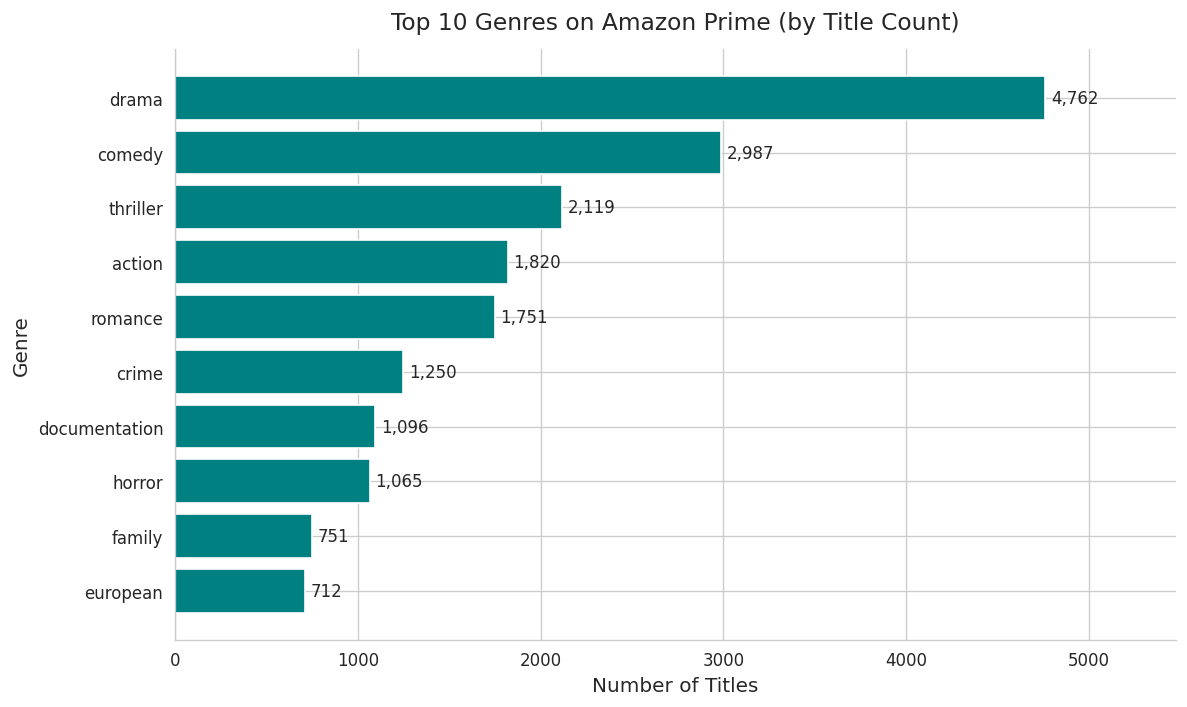

In [ ]:
# Chart - 3: Bar chart — Top 10 Genres by Frequency
genre_counts = titles_genres['genre'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='teal', edgecolor='white')
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)
ax.set_title('Top 10 Genres on Amazon Prime (by Title Count)', fontsize=14, pad=12)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Genre')
ax.set_xlim(0, genre_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** is used here because genre names are long strings that are easier to read horizontally. Ranking them from most to least frequent makes comparison straightforward.

##### 2. What is/are the insight(s) found from the chart?

**Drama** (4,764) and **Comedy** (2,987) are by far the two most prevalent genres on the platform, nearly double the frequency of the third-place genre, **Thriller** (2,119). Action, Romance, Crime, and Documentation also feature prominently. The platform has a clear bias toward mainstream, broadly appealing genres rather than niche ones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Knowing that Drama and Comedy dominate allows Amazon to continue investing in these genres and develop original content around them. **Risk:** Over-saturation of Drama and Comedy may make it harder for individual titles to stand out. Strategic investment in underrepresented but high-engagement genres like Sci-Fi, Animation, or Documentary could differentiate the platform.

#### Chart - 4 : Distribution of IMDb Scores

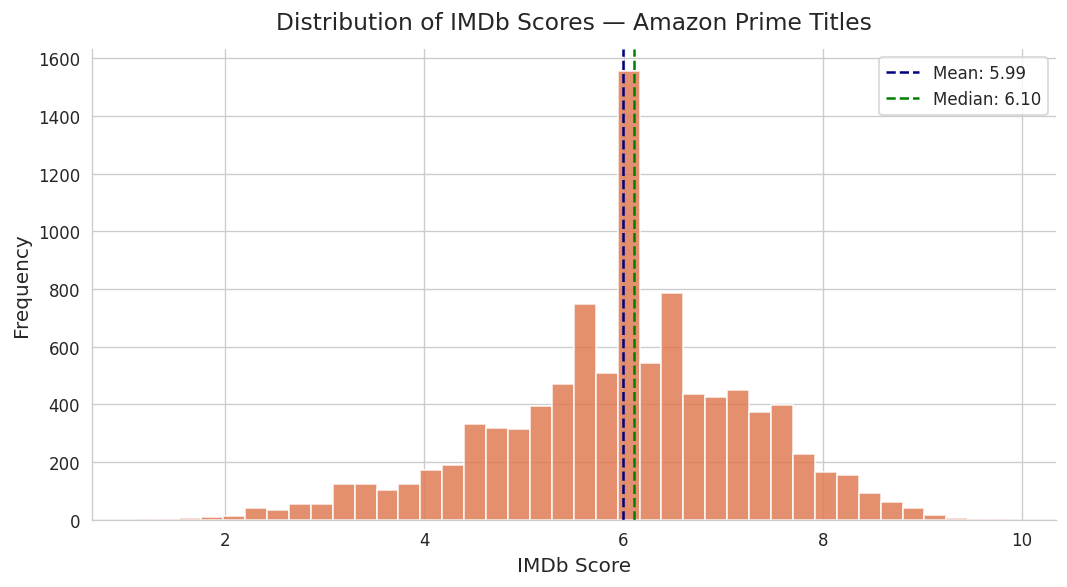

In [ ]:
# Chart - 4: Histogram — IMDb Score Distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(titles['imdb_score'], bins=40, color='#E07B54', edgecolor='white', alpha=0.85)
ax.axvline(titles['imdb_score'].mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f"Mean: {titles['imdb_score'].mean():.2f}")
ax.axvline(titles['imdb_score'].median(), color='green', linestyle='--', linewidth=1.5,
           label=f"Median: {titles['imdb_score'].median():.2f}")
ax.set_title('Distribution of IMDb Scores — Amazon Prime Titles', fontsize=14, pad=12)
ax.set_xlabel('IMDb Score')
ax.set_ylabel('Frequency')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **histogram with mean and median lines** clearly shows the shape of the IMDb score distribution. Including both central tendency measures helps identify any skew in the data.

##### 2. What is/are the insight(s) found from the chart?

IMDb scores on Amazon Prime are **approximately normally distributed**, centered around a mean of ~5.98 and median of ~6.10. The distribution has a slight left skew, indicating that more titles are clustered in the 5–7 range. Very few titles score above 8.5 or below 3.0, suggesting the platform avoids extremely low-quality content in its licensing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** A mean score near 6 suggests the library is of average-to-good quality. Titles in the 5–6 range could be improved in visibility through better recommendation placement. **Risk:** A significant portion of content scoring below 5 may create negative user experiences. Curating out very low-rated titles or de-prioritizing them in search rankings could improve average perceived quality.

#### Chart - 5 : IMDb Score by Content Type (Bivariate)

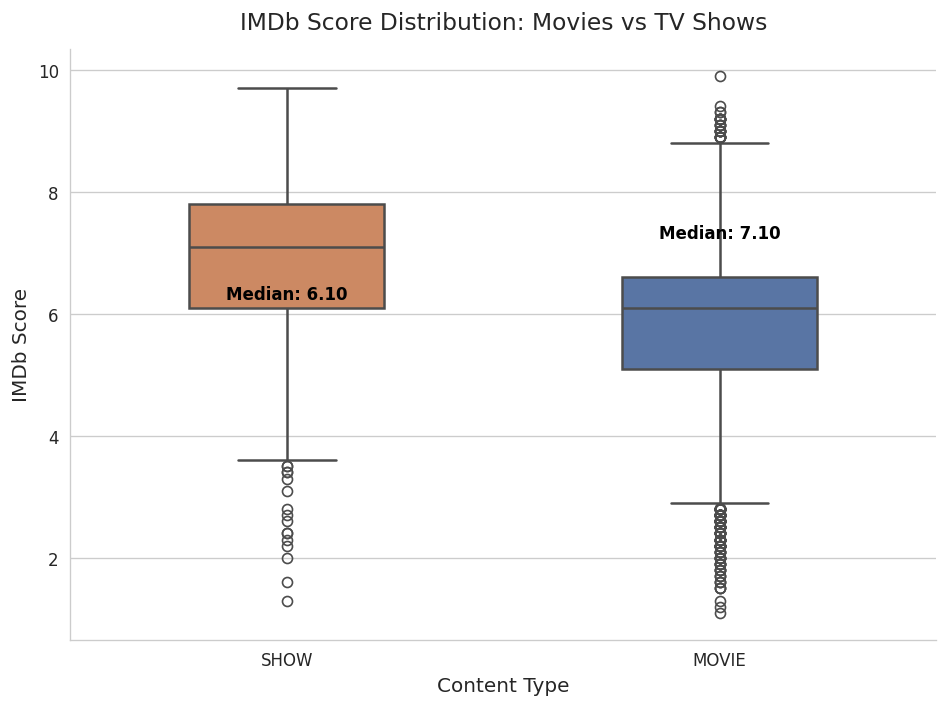

In [ ]:
# Chart - 5: Boxplot — IMDb Score by Content Type
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='type', y='imdb_score', data=titles, palette={'MOVIE': '#4C72B0', 'SHOW': '#DD8452'},
            width=0.45, linewidth=1.5, ax=ax)
ax.set_title('IMDb Score Distribution: Movies vs TV Shows', fontsize=14, pad=12)
ax.set_xlabel('Content Type')
ax.set_ylabel('IMDb Score')
# Annotate medians
for i, ctype in enumerate(['MOVIE', 'SHOW']):
    med = titles[titles['type']==ctype]['imdb_score'].median()
    ax.text(i, med + 0.15, f'Median: {med:.2f}', ha='center', fontsize=10, color='black', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **boxplot** is the best chart for comparing the distribution of a numerical variable across categories. It shows median, interquartile range, and outliers in a single compact view — perfect for comparing IMDb score distributions between content types.

##### 2. What is/are the insight(s) found from the chart?

TV Shows have a **notably higher median IMDb score (~6.80)** compared to Movies (~5.90). The box for shows is also narrower (less variance), indicating more consistent quality. Movies have a much wider spread and more low-scoring outliers. This confirms that the TV show catalog, though smaller in number, tends to be higher quality as rated by IMDb users.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** If Amazon Prime wants to improve perceived platform quality, investing in more TV show originals is the clear strategy — they consistently score higher. **Risk:** Movies with very low IMDb scores (below 4.0) are outliers that could harm the platform's reputation if they are prominently featured. A quality-gating policy for new movie acquisitions could help.

#### Chart - 6 : Average IMDb Score by Genre (Top 15)

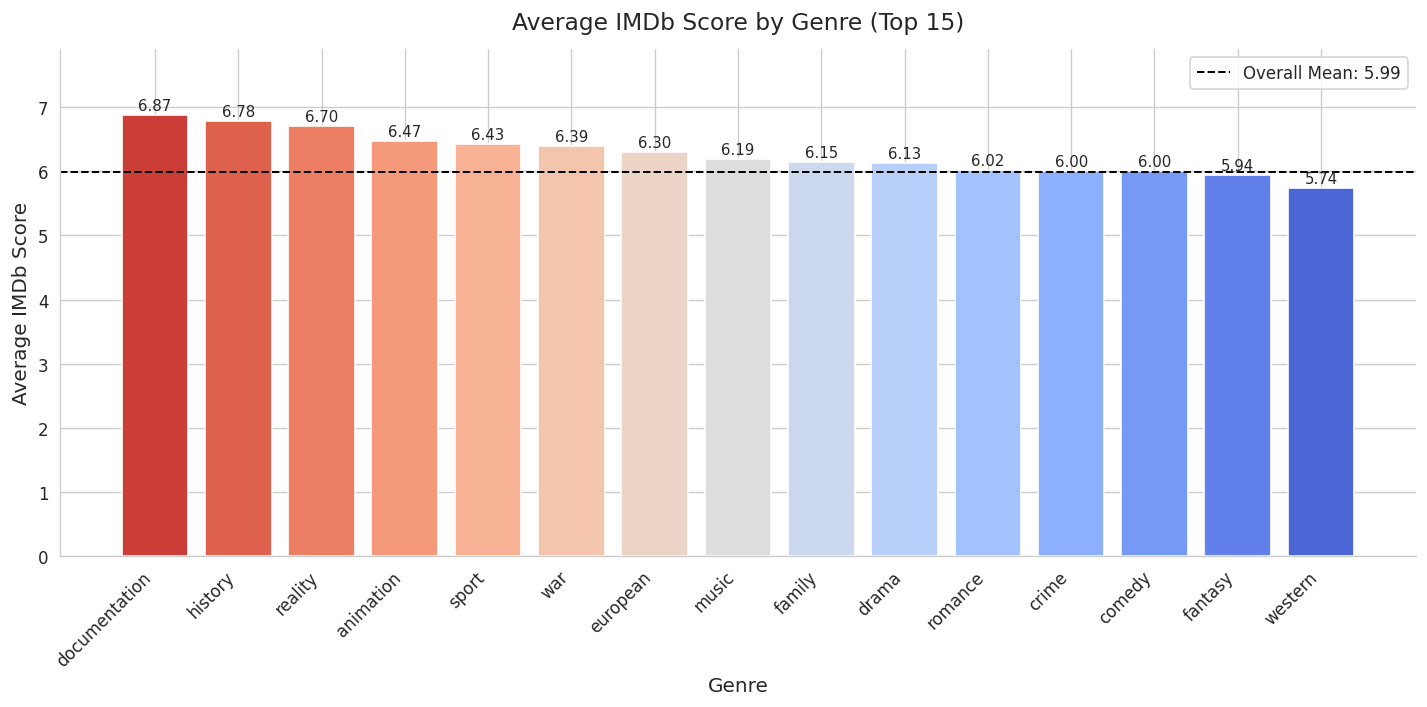

In [ ]:
# Chart - 6: Bar chart — Average IMDb Score by Genre
genre_rating = titles_genres.groupby('genre')['imdb_score'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('coolwarm_r', len(genre_rating))
bars = ax.bar(genre_rating.index, genre_rating.values, color=palette, edgecolor='white')
ax.axhline(titles['imdb_score'].mean(), color='black', linestyle='--', linewidth=1.2,
           label=f"Overall Mean: {titles['imdb_score'].mean():.2f}")
for bar, val in zip(bars, genre_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Average IMDb Score by Genre (Top 15)', fontsize=14, pad=12)
ax.set_xlabel('Genre')
ax.set_ylabel('Average IMDb Score')
ax.set_ylim(0, genre_rating.max() * 1.15)
ax.legend()
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **colored bar chart** with a reference line (overall mean) makes it easy to see which genres score above or below the platform average. Sorting by score creates a natural ranking that aids interpretation.

##### 2. What is/are the insight(s) found from the chart?

Genres like **History, War, and Music** tend to have the highest average IMDb scores, while genres like **Horror, Reality, and Erotic** rank lower. Many high-volume genres (Drama, Comedy) score close to the platform average (~5.98), suggesting that popularity and quality are not always correlated. Niche genres with fewer titles tend to have higher average ratings, possibly due to selection bias (only the best niche content gets licensed).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Amazon could boost user satisfaction by promoting high-rated-but-low-volume genres like History and War documentaries, which offer strong quality signals. **Risk:** Overinvesting in niche genres may not translate to broad viewership growth. A balanced portfolio strategy — anchored by Drama and Comedy with quality accents from History/War — is recommended.

#### Chart - 7 : Number of Titles Released Per Year (Trend)

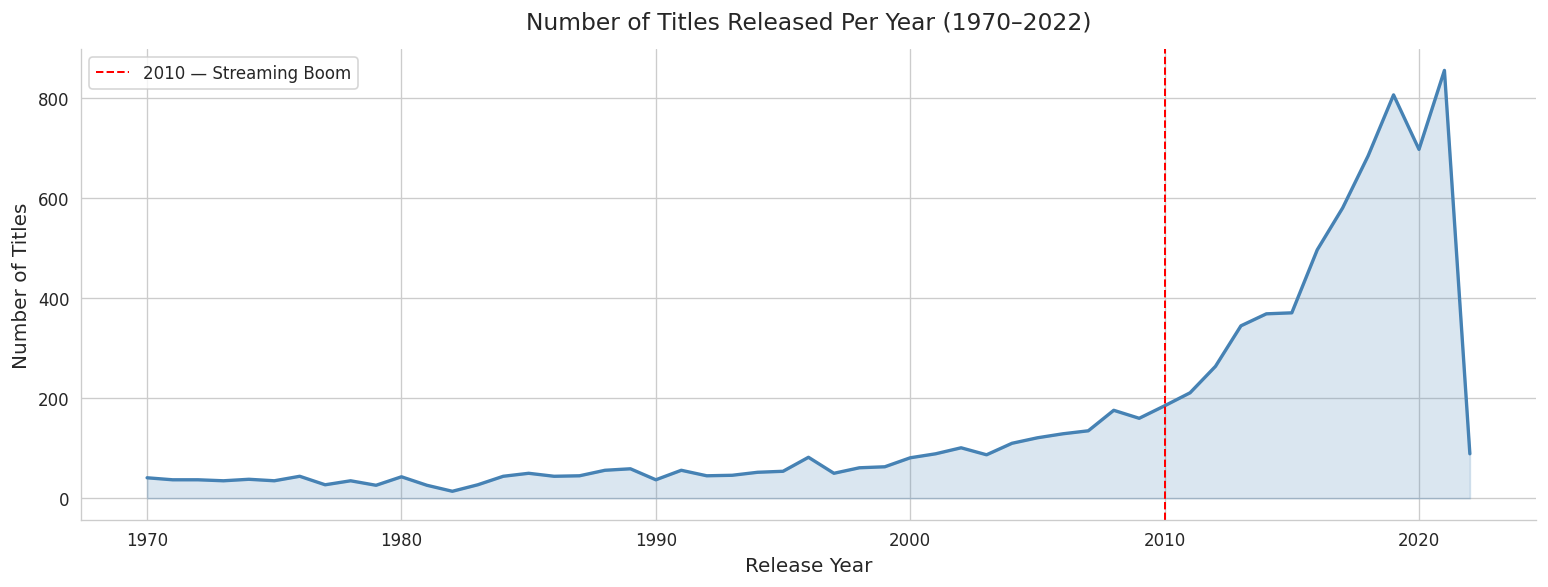

In [ ]:
# Chart - 7: Line chart — Titles released per year
yearly = titles.groupby('release_year').size().reset_index(name='count')
yearly = yearly[yearly['release_year'] >= 1970]  # Focus on modern era

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(yearly['release_year'], yearly['count'], alpha=0.2, color='steelblue')
ax.plot(yearly['release_year'], yearly['count'], color='steelblue', linewidth=2)
ax.set_title('Number of Titles Released Per Year (1970–2022)', fontsize=14, pad=12)
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.axvline(2010, color='red', linestyle='--', linewidth=1.2, label='2010 — Streaming Boom')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **line chart with area fill** is ideal for showing trends over continuous time. The filled area gives a strong visual sense of how dramatically content volume has grown in recent decades.

##### 2. What is/are the insight(s) found from the chart?

Title releases remained relatively flat from 1970–2000 (typically fewer than 200 per year). The number begins climbing steeply after 2000 and **explodes post-2010**, peaking around 2019–2020. This directly reflects the streaming boom and the rapid expansion of Amazon Prime Video's library through licensing and original content production. The slight decline after 2020 may be due to COVID-19 production slowdowns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The steep growth trend shows Amazon's aggressive content expansion strategy is working in terms of volume. **Risk:** Rapid volume growth without quality filtering could dilute the average rating, leading to user experience degradation. Amazon should balance quantity with curation.

#### Chart - 8 : IMDb Score vs TMDb Popularity (Scatter)

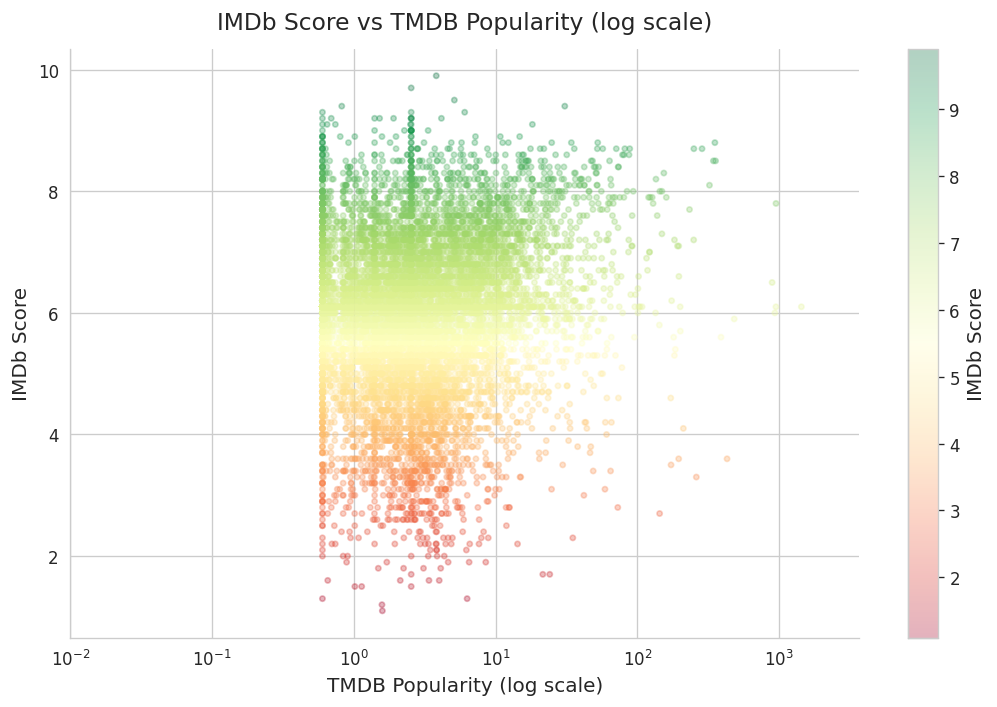

In [ ]:
# Chart - 8: Scatter plot — IMDb Score vs TMDb Popularity
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(titles['tmdb_popularity'], titles['imdb_score'],
                alpha=0.3, c=titles['imdb_score'], cmap='RdYlGn', s=10)
plt.colorbar(sc, ax=ax, label='IMDb Score')
ax.set_xscale('log')
ax.set_title('IMDb Score vs TMDB Popularity (log scale)', fontsize=14, pad=12)
ax.set_xlabel('TMDB Popularity (log scale)')
ax.set_ylabel('IMDb Score')
ax.set_xlim(left=0.01)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot** is the standard tool for exploring the relationship between two continuous numerical variables. A log scale on the x-axis is used because `tmdb_popularity` is heavily right-skewed (a few viral titles have extreme values).

##### 2. What is/are the insight(s) found from the chart?

There is **no strong linear correlation** between IMDb score and TMDb popularity. Most titles cluster in the low-popularity, medium-score region. A few titles have extremely high TMDb popularity but average IMDb scores — indicating that viral popularity does not necessarily mean critical quality. High IMDb scores (>8) are scattered across different popularity levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Amazon should not rely solely on TMDb popularity as a proxy for content quality when making acquisition decisions. Using a composite score (both ratings + popularity) will lead to better curated libraries. **Risk:** Highly popular but low-rated content may still attract clicks but lead to high drop-off rates, negatively impacting watch time metrics.

#### Chart - 9 : Titles Per Decade by Genre (Heatmap)

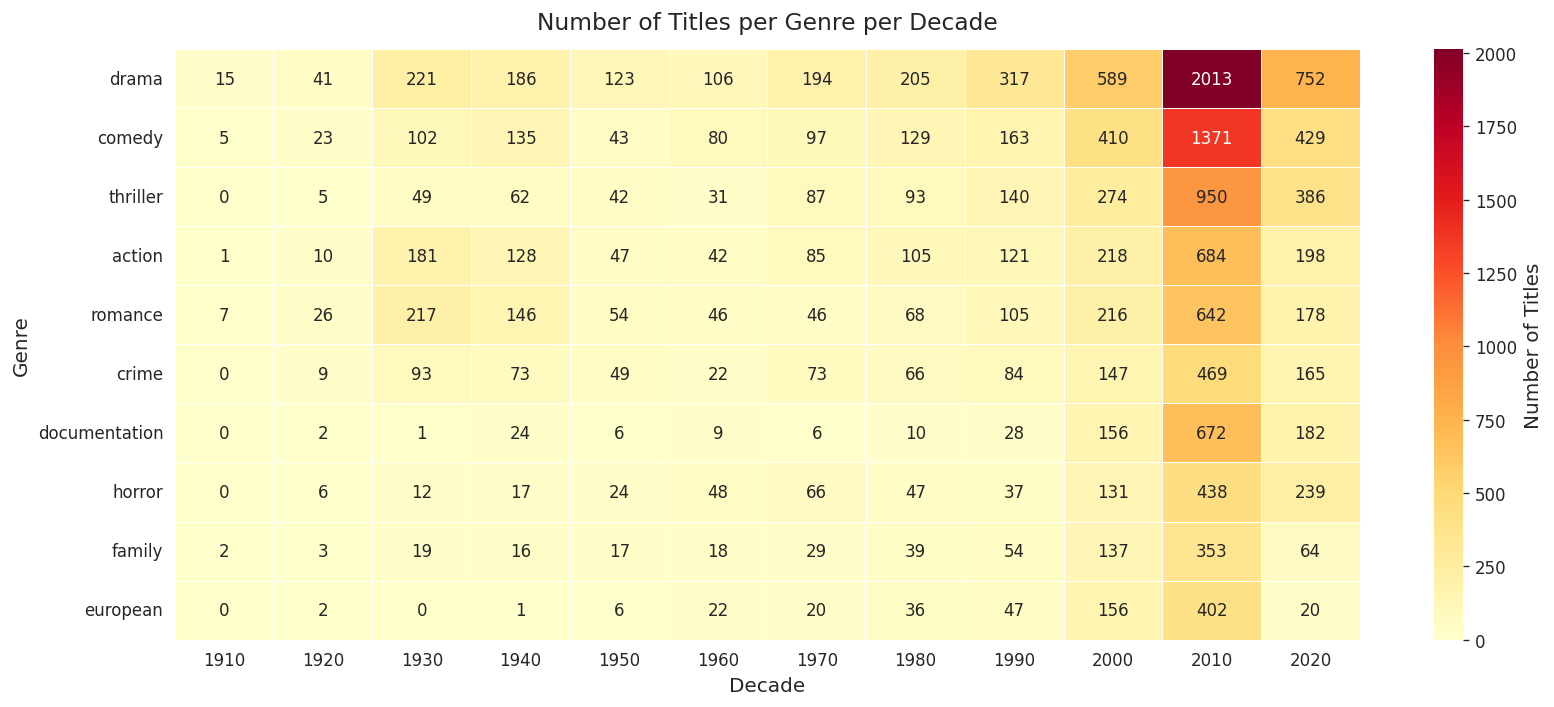

In [ ]:
# Chart - 9: Heatmap — Titles per Genre per Decade
top_genres_list = titles_genres['genre'].value_counts().head(10).index.tolist()
genre_decade = titles_genres[titles_genres['genre'].isin(top_genres_list)]
pivot = genre_decade.groupby(['decade','genre']).size().unstack(fill_value=0)
pivot = pivot[[g for g in top_genres_list if g in pivot.columns]]  # keep order

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot.T, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'Number of Titles'}, ax=ax)
ax.set_title('Number of Titles per Genre per Decade', fontsize=14, pad=12)
ax.set_xlabel('Decade')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **heatmap** is ideal for visualizing a two-dimensional relationship between two categorical variables (genre × decade) and a numerical value (count). The color gradient immediately highlights which genre-decade combinations dominate.

##### 2. What is/are the insight(s) found from the chart?

The **2010s decade dominates across all genres** with dramatically higher counts than any other decade — especially Drama (2,000+) and Comedy. This confirms the post-2010 streaming explosion. Prior to 2000, Drama and Action were the most common genres in the catalog. The Documentation and Romance genres have grown significantly in the 2010s, reflecting changing streaming audience preferences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Genre growth trends by decade help Amazon forecast future content needs. Drama and Comedy will likely continue to dominate — Amazon can plan multi-year content deals accordingly. **Risk:** The extreme concentration in the 2010s decade may mean the catalog is heavily skewed toward recent tastes, potentially alienating older subscribers who prefer classic content from earlier decades.

#### Chart - 10 : Stacked Bar — Genre Distribution by Content Type

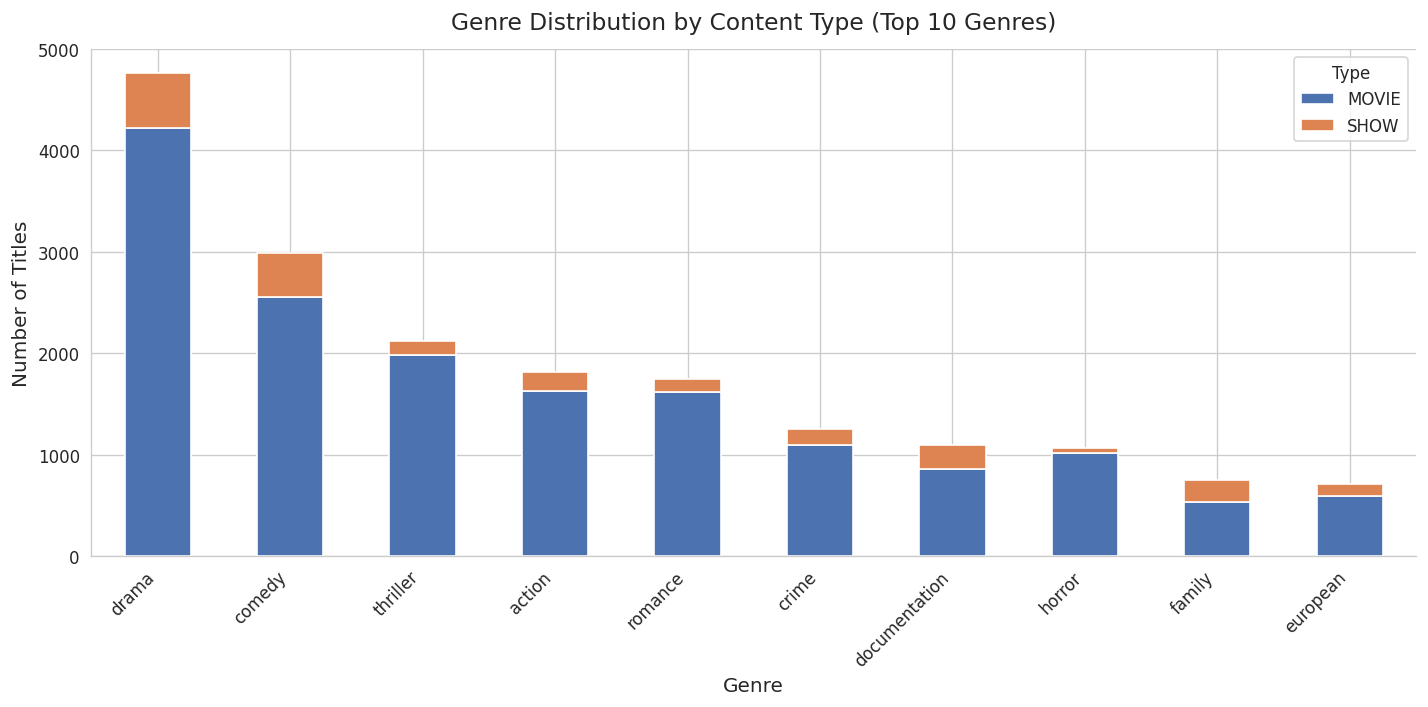

In [ ]:
# Chart - 10: Stacked bar — Top genres split by MOVIE vs SHOW
top10_genres = titles_genres['genre'].value_counts().head(10).index
genre_type = titles_genres[titles_genres['genre'].isin(top10_genres)]
pivot_type = genre_type.groupby(['genre','type']).size().unstack(fill_value=0)
pivot_type = pivot_type.loc[top10_genres]  # maintain ranking order

pivot_type.plot(kind='bar', stacked=True, figsize=(12, 6),
                color={'MOVIE': '#4C72B0', 'SHOW': '#DD8452'}, edgecolor='white')
plt.title('Genre Distribution by Content Type (Top 10 Genres)', fontsize=14, pad=12)
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?  
A **stacked bar chart** shows both the total frequency of each genre and the within-genre split between movies and shows, enabling a rich bivariate comparison in a single view.
##### 2. What is/are the insight(s) found from the chart?  
Across all top genres, **movies dominate in raw count**. However, TV shows have a relatively stronger representation in genres like **Documentation** and **Family**, suggesting these genres are more naturally suited to series format. Drama has the highest show presence in absolute numbers. Comedy is almost entirely movie-driven.
##### 3. Will the gained insights help creating a positive business impact?  
**Positive impact:** Genre-type affinity guides content format decisions — e.g., commissioning documentary series rather than feature films may be more aligned with audience expectations in that genre. **Risk:** Mismatching format and genre (e.g., a 90-minute documentary film in a landscape dominated by series docs) may lead to lower completion rates.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the EDA conducted on Amazon Prime Video's content library, the following data-driven recommendations are made:

**1. Invest more in original TV show productions.**
TV shows have a significantly higher median IMDb score (~6.80) compared to movies (~5.90). Despite making up only 14% of the catalog, they tend to be higher-quality and drive extended subscriber engagement through multi-season viewing. Amazon should increase the ratio of original series, especially in Drama, Comedy, and Documentation — the three largest genres.

**2. Expand content from high-scoring international markets.**
Japan, South Korea, and certain European countries (DE, FR) produce content that scores above the platform average on IMDb. Investing in content partnerships with studios from these regions (as Netflix did with Korean dramas) would broaden Amazon Prime's appeal to non-English-speaking markets and differentiate its catalog.

**3. Improve quality curation for the movie catalog.**
With movies making up 86% of the catalog and having a lower average IMDb score, Amazon should implement a quality threshold for new movie acquisitions (e.g., minimum IMDb score of 5.5 with at least 100 votes). Titles scoring below 4.0 should be reviewed for removal or de-prioritization in recommendations.

**4. Develop a 'Classic Cinema' category hub.**
The catalog contains a large and surprisingly high-rated collection of pre-1970 content — especially Westerns. Packaging this content into a branded 'Classic Hollywood' or 'Golden Age Westerns' section could attract a niche but loyal subscriber segment and maximize the ROI of already-licensed content.

**5. Use IMDb and TMDb scores together as a composite quality signal.**
The strong correlation between IMDb score and TMDb score (0.58) validates using both as complementary signals. Amazon's content recommendation and acquisition teams should use a composite score (weighted average of both) to rank content, as neither alone captures the full picture of audience reception.


# **Conclusion**

This Exploratory Data Analysis of Amazon Prime Video's content library — covering 9,871 titles and 124,235 credits — has yielded several meaningful insights into the platform's content strategy, genre composition, ratings landscape, and international reach.

The platform is **movie-heavy** (86%) but TV shows consistently **outperform movies in audience ratings**, suggesting a strategic case for expanding the show catalog. Drama and Comedy dominate by volume, but niche genres like History, War, and Music achieve higher average quality ratings. The US, India, and UK account for over 70% of all content, revealing both the platform's Anglo-American bias and an opportunity to diversify toward high-performing international markets.

The **post-2010 streaming boom** is clearly reflected in the release year distribution, with content volume increasing exponentially after 2010. IMDb and TMDb scores are strongly correlated (0.58), confirming they can be used interchangeably or combined as a composite quality signal. Vintage Western content from pre-1960 is unexpectedly well-represented and highly rated, offering a niche audience opportunity.

**Limitations:** The heavy missingness in `age_certification` (~66%) limits audience segmentation analysis. Ratings data (IMDb votes) is highly skewed — some titles have hundreds of thousands of votes while others have just a few, which affects the reliability of average score comparisons. Viewership data (actual streaming counts) is unavailable, making it impossible to measure engagement vs. catalog presence.

**Future directions:** This EDA can be extended with NLP analysis of title descriptions to identify content themes, predictive modeling of IMDb scores using genre/country/type features, and time-series forecasting of content volume growth. Integration with viewership metrics would also unlock actionable retention and recommendation insights.
